In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Motif binding score (see analysis code for calculation)
binding_data_dir = "binding_score_at_motifs"
erg_binding_csv = f"{binding_data_dir}/ERG/ERG__orig-human__loc-prom__motif-GABPA.H12CORE.0.PSM.A__type-family__fl25__nuc-7-25-50__trim150.csv"

# Background z-score array (numpy .npy or similar)
background_binding_dir = f"{binding_data_dir}/background_binding_arrays"
erg_bg_windows_path = f"{background_binding_dir}/ERG__orig-human__loc-prom__signal_bg__fl25.npy"

## Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Helper Functions

In [4]:
# Split dataframe into FIMO score groups
def fimo_threshold_subsets(df, fimo_col="fimo_score", n_groups=3):
    s = pd.to_numeric(df[fimo_col], errors="coerce").dropna()
    u = np.sort(s.unique())
    idxs = np.array_split(np.arange(u.size), n_groups)
    thresholds = [float(u[i[0]]) for i in idxs if len(i) > 0]
    subsets = [df[pd.to_numeric(df[fimo_col], errors="coerce") >= t] for t in thresholds]
    return thresholds, subsets

## Data Loading

In [5]:
# Load data
erg_bg_windows = np.load(erg_bg_windows_path, mmap_mode=None)
erg_bg_z = erg_bg_windows[:,1]
erg_binding_df = pd.read_csv(erg_binding_csv)

## Plotting


=== z>3 summary ===
Background: n_bg=4363940, n_bg(z>3)=27423, n_bg(z>3)/51=537.706
Low FIMO: n_motifs=1101, n_motifs(z>3)=139, 100*motifs_gt3/(bg_gt3/51) = 25.85
Mid FIMO: n_motifs=506, n_motifs(z>3)=83, 100*motifs_gt3/(bg_gt3/51) = 15.44
High FIMO: n_motifs=171, n_motifs(z>3)=41, 100*motifs_gt3/(bg_gt3/51) = 7.62


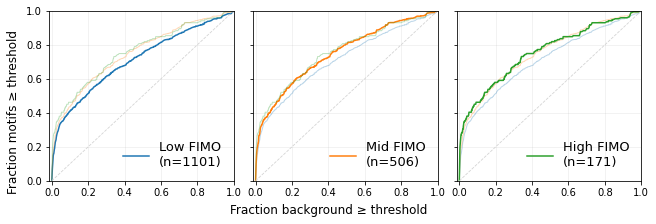

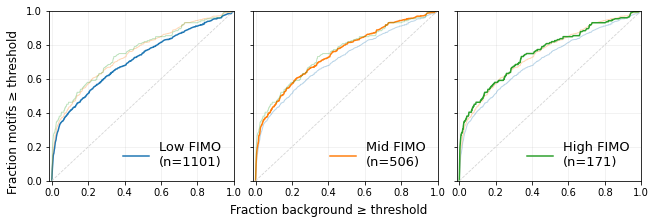

In [6]:
# Plot ROC-style curves for FIMO groups with summaries
def plot_pct_windows_vs_motif_threshold_groups_highlight_tripanel(
    z_array,
    df,
    z_col="z_score",
    fimo_col="fimo_score",
    sample_name="",
    n_groups=3,
):

    _, subsets = fimo_threshold_subsets(df, fimo_col=fimo_col, n_groups=n_groups)

    bg = np.asarray(z_array).ravel()
    bg = bg[np.isfinite(bg)]
    if bg.size == 0:
        fig, _ = plt.subplots(1, 3, figsize=(9, 3), constrained_layout=True)
        return fig

    z_thr = 3.0
    window_size = 51

    bg_gt3 = int(np.sum(bg > z_thr))
    bg_units = bg_gt3 / window_size

    if n_groups == 3:
        labels = ["Low FIMO", "Mid FIMO", "High FIMO"]
    else:
        labels = [f"Group {i+1}" for i in range(n_groups)]

    print("\n=== z>3 summary" + (f" ({sample_name})" if sample_name else "") + " ===")
    print(f"Background: n_bg={bg.size}, n_bg(z>3)={bg_gt3}, n_bg(z>3)/{window_size}={bg_units:.3f}")

    for label, sub in zip(labels, subsets):
        z_sub = pd.to_numeric(sub[z_col], errors="coerce").dropna().to_numpy()
        motifs_gt3 = int(np.sum(z_sub > z_thr))
        ratio = np.nan if bg_units == 0 else 100.0 * motifs_gt3 / bg_units

        print(
            f"{label}: n_motifs={len(z_sub)}, n_motifs(z>3)={motifs_gt3}, "
            f"100*motifs_gt3/(bg_gt3/{window_size}) = {ratio:.2f}"
        )

    qs = np.linspace(0, 1, 1000)
    thr = np.quantile(bg, qs)

    motif_max = pd.to_numeric(df[z_col], errors="coerce").max()
    tmax = np.nextafter(max(np.max(bg), motif_max), np.inf)
    thr = np.r_[thr, tmax]

    bg_sorted = np.sort(bg)
    x = (bg_sorted.size - np.searchsorted(bg_sorted, thr, side="left")) / bg_sorted.size

    curves = []
    for label, sub in zip(labels, subsets):
        z = pd.to_numeric(sub[z_col], errors="coerce").dropna().to_numpy()
        if z.size == 0:
            curves.append({"label": label, "x": x, "y": None, "n": 0})
            continue
        z_sorted = np.sort(z)
        y = (z_sorted.size - np.searchsorted(z_sorted, thr, side="left")) / z_sorted.size
        curves.append({"label": label, "x": x, "y": y, "n": z_sorted.size})

    fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharex=True, sharey=True, constrained_layout=True)

    highlight_idxs = list(range(min(3, len(curves))))

    for ax, hi in zip(axes, highlight_idxs):
        for i, c in enumerate(curves):
            if c["y"] is None:
                continue
            is_hi = (i == hi)
            alpha = 1.0 if is_hi else 0.3
            lw = 1.5 if is_hi else 1
            line_label = f'{c["label"]}\n(n={c["n"]})' if is_hi else "_nolegend_"
            ax.plot(c["x"], c["y"], alpha=alpha, label=line_label, lw=lw)

        ax.plot([0, 1], [0, 1], "--", lw=0.8, color="lightgray")
        ax.set_xlim(-0.015, 1)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.2)
        ax.legend(frameon=False, fontsize=13, loc="lower right")

    fig.supxlabel("Fraction background ≥ threshold")
    fig.supylabel("Fraction motifs ≥ threshold")

    plt.show()
    return fig


plot_pct_windows_vs_motif_threshold_groups_highlight_tripanel(
    erg_bg_z,
    erg_binding_df,
)